In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install autocorrect
!pip install pyspellchecker
!pip install contractions
!pip install seaborn
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [9]:
# Importing Packages
import pandas as pd #to work with frames
import re # regular expressions for preprocessing
import spacy
import nltk
import tensorflow as tf
from spellchecker import SpellChecker
import multiprocessing as mp
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from itertools import combinations
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

1. Import dataset

In [36]:
# Read the content of the text file into a string variable:
# Please make sure the path to your text file is correct.
text_file_path = '/content/drive/MyDrive/Colab Notebooks/NER/reading.txt' # !!! UPDATE THIS PATH TO YOUR TEXT FILE !!!

try:
    with open(text_file_path, 'r', encoding='utf-8') as f:
        single_text = f.read()
    print(f"Successfully loaded text from {text_file_path}")
except FileNotFoundError:
    print(f"Error: The file '{text_file_path}' was not found. Please check the path.")
    single_text = ""
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
    single_text = ""

Successfully loaded text from /content/drive/MyDrive/Colab Notebooks/NER/reading.txt


In [28]:
# Display the first few characters of the loaded text:
print("First 500 characters of the loaded text:")
print(single_text[:500])

First 500 characters of the loaded text:
Geschichte und Baugeschichte. St. Fiden wurde erst im Jahre 1918 durch die Eingemeindung von Tablat, dem die Siedlung zugehörte, ein Teil des Stadtgebietes. Die Grenze zwischen dem alten Stadtterritorium und der Landschaft ging mitten durch ein zunächst der Kirche gelegenes Haus hindurch, das im Jahre 1426 durch einen Spruch der Räte der städtischen Gerichtsbarkeit zugeteilt wurde (Vad. I, S.365). Die Ortschaft verdankte, wie schon der Name erkennen läßt, allein der Kirche, die bis 1777 den Tite


Data Cleaning and Preprocessing

# OCR cleanup (footnote artifacts)

Before spell-checking or tokenizing, fix OCR-specific artifacts rather than language issues: footnote markers the OCR misread as `!`, `?`, `*` and glued onto word endings, plus surviving superscript digits. This is conservative — only patterns that cannot be genuine German punctuation are touched; a real uncertainty marker like `(St. Ludwig?)` is deliberately left alone. Ported from `ner_workflow.ipynb`, where these patterns were verified against this same corpus.

In [29]:
import re

# OCR footnote artifacts, verified against this corpus in ner_workflow.ipynb. German never
# has '!'/'?' directly before ',' or '.', and a '?' followed by a lowercase word mid-sentence
# is a misread superscript footnote digit. Genuine uncertainty markers like "(St. Ludwig?)"
# or "…oder Walburga? Umschrift…" are deliberately NOT matched.
OCR_CLEANUP_PATTERNS = [
    ("footnote '*' glued to a word", re.compile(r"(?<=[\wäöüÄÖÜß»)])\*")),
    ("'!'/'?'/'*' before ',' or '.'", re.compile(r"\s?[!?*]+(?=[.,])")),
    ("'?' mid-sentence before lowercase", re.compile(r"(?<=[a-zäöüß])\?(?=\s[a-zäöüß])")),
    ("surviving superscript digits", re.compile(r"[¹²³⁴⁵⁶⁷⁸⁹⁰]+")),
    ("footnote quote/degree marks (1777'. / 1779°.)", re.compile(r"(?<=[\wäöüß])[''`°](?=[.,])")),
]

def show_ocr_matches(pattern, text, label, width=40):
    hits = list(pattern.finditer(text))
    print(f"{label}: {len(hits)} match(es)")
    for m in hits[:20]:
        s = max(0, m.start() - width)
        print("   …", text[s : m.end() + width].replace("\n", " "), "…")
    print()

if single_text:
    ocr_cleaned_text = single_text
    for label, pattern in OCR_CLEANUP_PATTERNS:
        show_ocr_matches(pattern, ocr_cleaned_text, label)
        ocr_cleaned_text = pattern.sub("", ocr_cleaned_text)
    ocr_cleaned_text = re.sub(r"[ \t]{2,}", " ", ocr_cleaned_text)

    print(f"cleaned: {len(single_text) - len(ocr_cleaned_text)} characters removed")

    # Every downstream cell reads from 'single_text', so update it in place once
    # OCR cleanup has run — spell-check, tokenization, and NER all benefit.
    single_text = ocr_cleaned_text
else:
    print("No text loaded for OCR cleanup.")

footnote '*' glued to a word: 4 match(es)
   … uteil gewordenen Auftrag in Zusammenhang*. Mag die Sage auch der Kritik nicht sta …
   … tha³, 1644 schenkte Abt Pius eine Glocke* und am 31. Juli 1661 fand nach umfassen …
   …  Friedhofes, anstoßend an das Pfrundhaus*. Die älteste Ansicht gibt uns das linke …
   … f dem Bild im Chor: «Antoni Dick pinx. »*.  Ausstattung Die Altäre, Die Kirche be …

'!'/'?'/'*' before ',' or '.': 9 match(es)
   … ichbohl» (Eichenhügel) oder auch «Farna»!, Die Legende bringt die Gründung der Ki …
   … ngen, wo die Gebeine der Heiligen ruhten?, Bei der wohl auf Reliquienübertragung  …
   … Lattengewölbe, die Schindeln und anderes?, Obwohl die neue Kirche nicht auf dem A …
   … am 14. Juli 1778 auch der Turm vollendet!?, Die Deckenmalereien schuf Antoni Dick  …
   … ht der mit einem Spitzhelm bekrönte Turm?. In gleicher Höhe mit den rundbogigen F …
   …  der Kirche erstreckte sich der Friedhof *. Um 1749/50 fügte man der Kirche gegen  …
   … das Gebälk segmen

Spell check

In [ ]:
from spellchecker import SpellChecker

# Initialize the spell checker for German
spell = SpellChecker(language='de')

def correct_text_spelling(input_text):
    """
    Corrects spelling of a single input text using the initialized SpellChecker.
    """
    # Split the text into words
    words = input_text.split()
    corrected_words = []
    for word in words:
        # Correct each word and add it to the list
        corrected_words.append(spell.correction(word))
    # Join the corrected words back into a sentence
    return ' '.join([word for word in corrected_words if word is not None])

# Example usage with German text:
example_text = "Das ist ein beispeil von falsch geschribenem text."
corrected_example_text = correct_text_spelling(example_text)
print(f"Original text: {example_text}")
print(f"Corrected text: {corrected_example_text}")

Original text: Das ist ein beispeil von falsch geschribenem text.
Corrected text: Das ist ein beispiel von falsch geschriebenem text


In [ ]:
import re

# Apply German spell checking to the 'single_text'.
# The 'spell' object and 'correct_text_spelling' function are defined in cell '_mUqkUT1VmM1'.

def clean_text(input_text):
    # Do not convert to lowercase here, as spell_corrected_text preserves original casing where possible.
    text = input_text
    # Remove punctuation and digits. Keep only alphabetic characters and spaces.
    text = re.sub(r'[^a-zäöüßA-ZÄÖÜ\n\t\r\f\u00A0\u200B\u200C\u200D\u200E\u200F\u2028\u2029]+', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text


if single_text:
    # First, correct spelling
    spell_corrected_text = correct_text_spelling(single_text)
    # Then, clean the text (after spelling, punctuation/digit removal, without forced lowercase)
    cleaned_text = clean_text(spell_corrected_text)

    print("Original text (first 200 chars):\n", single_text[:200])
    print("\nSpell-corrected text (first 200 chars):\n", spell_corrected_text[:200])
    print("\nCleaned text (after spelling, punctuation/digit removal - first 200 chars):\n", cleaned_text[:200])
else:
    print("No text loaded for spell correction and cleaning.")
    cleaned_text = ""

Original text (first 200 chars):
 Geschichte und Baugeschichte. St. Fiden wurde erst im Jahre 1918 durch die Eingemeindung von Tablat, dem die Siedlung zugehörte, ein Teil des Stadtgebietes. Die Grenze zwischen dem alten Stadtterritor

Spell-corrected text (first 200 chars):
 Geschichte und st finden wurde erst im Jahre 1918 durch die von tablett dem die Siedlung zugehörte ein Teil des stadtgebiete Die Grenze zwischen dem alten und der Landschaft ging mitten durch ein zunä

Cleaned text (after spelling, punctuation/digit removal - first 200 chars):
 Geschichte und st finden wurde erst im Jahre durch die von tablett dem die Siedlung zugehörte ein Teil des stadtgebiete Die Grenze zwischen dem alten und der Landschaft ging mitten durch ein zunächst 


## Save Cleaned Text

To avoid re-running the cleaning and preprocessing steps every time, we'll save the `cleaned_text` to a file. This allows for quicker iteration and development.


In [ ]:
import joblib
import os

if cleaned_text:
    # Determine the directory of the original text file
    output_dir = os.path.dirname(text_file_path)
    # Define the output file path for the cleaned text
    cleaned_text_output_path = os.path.join(output_dir, 'cleaned_text.pkl')

    # Save the cleaned text using joblib
    joblib.dump(cleaned_text, cleaned_text_output_path)

    print(f"Cleaned text saved to: {cleaned_text_output_path}")

    # Optionally, you can load it back to verify
    # loaded_cleaned_text = joblib.load(cleaned_text_output_path)
    # print("Loaded cleaned text (first 500 chars):")
    # print(loaded_cleaned_text[:500])
else:
    print("No cleaned text available to save.")


Cleaned text saved to: /content/drive/MyDrive/Colab Notebooks/NER/cleaned_text.pkl


The tokenize → lemmatize → remove-stopwords chain (cells 13–17) only feeds into the TF-IDF analysis further down.

Tokenization

In [10]:
# Download the German spaCy model
# If this is run in a new environment, it might need to be executed once.
!python -m spacy download de_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 47.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Tokenization and Lemmatization

In [ ]:
# Function to tokenize and lemmatize text using spaCy
def tokenize_and_lemmatize_text(text):
    # The 'nlp' object is expected to be loaded globally (e.g., in cell '5TYXDvFjWe9Q')
    if pd.isna(text) or not text.strip(): # Check for empty or whitespace-only strings
        return []  # Return empty list for missing or empty values
    doc = nlp(text)
    # Extract lemmas and ensure they are not just whitespace or punctuation after lemmatization
    lemmas = [token.lemma_ for token in doc if token.lemma_.strip() and not token.is_punct and not token.is_space and not token.like_num]
    return lemmas


In [ ]:
import spacy

# Apply Tokenization and Lemmatization to the 'cleaned_text' using the German spaCy model.
# The 'tokenize_and_lemmatize_text' function is defined in cell '237751de'.

# Ensure nlp model is loaded if not already. This is added to prevent NameError
# if this cell is executed before the main spaCy loading cell (5TYXDvFjWe9Q).
try:
    # Check if nlp is already defined globally
    _ = nlp
except NameError:
    print("Loading spaCy German model within this cell as 'nlp' was not found.")
    nlp = spacy.load("de_core_news_sm")

if cleaned_text:
    tokenized_lemmatized_text = tokenize_and_lemmatize_text(cleaned_text)
    print("Tokenized and Lemmatized text (first 20 tokens):\n", tokenized_lemmatized_text[:20])
else:
    print("No cleaned text available for tokenization and lemmatization.")
    tokenized_lemmatized_text = []


Loading spaCy German model within this cell as 'nlp' was not found.
Tokenized and Lemmatized text (first 20 tokens):
 ['st', 'finden', 'der', 'Kirche', 'zu', 'herz', 'Jesu', 'in', 'st', 'finden', 'Geschichte', 'und', 'st', 'finden', 'werden', 'erst', 'in', 'Jahr', 'durch', 'der']


Stop words

In [ ]:
# Download NLTK's German stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

# Load German stopwords
german_stopwords = set(stopwords.words('german'))

def remove_german_stopwords(tokens):
    if not tokens: # Handle empty list
        return []
    # Filter out stopwords AND tokens shorter than 3 characters
    filtered_tokens = [token for token in tokens if token.lower() not in german_stopwords and len(token) >= 3]
    return filtered_tokens

# Apply stopword removal to the 'tokenized_lemmatized_text'
if tokenized_lemmatized_text:
    # NLTK stopwords are typically lowercase, so we ensure tokens are also lowercase for comparison
    # The lemmatized tokens are already mostly lowercase, but an additional lower() call ensures consistency
    no_stopwords_tokens = remove_german_stopwords(tokenized_lemmatized_text)
    no_stopwords_text = ' '.join(no_stopwords_tokens)
    print("Text after stopword removal and short token filtering (first 200 chars):\n", no_stopwords_text[:200])
    print("\nNumber of tokens after stopword removal:", len(no_stopwords_tokens))
else:
    print("No tokenized and lemmatized text available for stopword removal.")
    no_stopwords_text = ""
    no_stopwords_tokens = []

Text after stopword removal and short token filtering (first 200 chars):
 finden Kirche herz Jesu finden Geschichte finden erst Jahr Tablett Siedlung zugehören Teil Stadtgebiete Grenze alt Landschaft gehen mitten zunächst Kirche gelegen Haus hindurch Jahr Spruch räte städti

Number of tokens after stopword removal: 2073


## Save Text After Stopword Removal

Saving the text after stopword removal allows you to bypass these preprocessing steps in subsequent sessions, speeding up your workflow.

In [ ]:
import joblib
import os

if no_stopwords_text:
    # Determine the directory of the original text file
    output_dir = os.path.dirname(text_file_path)
    # Define the output file path for the text after stopword removal
    no_stopwords_text_output_path = os.path.join(output_dir, 'no_stopwords_text.pkl')

    # Save the text using joblib
    joblib.dump(no_stopwords_text, no_stopwords_text_output_path)

    print(f"Text after stopword removal saved to: {no_stopwords_text_output_path}")

    # Optionally, you can load it back to verify
    # loaded_no_stopwords_text = joblib.load(no_stopwords_text_output_path)
    # print("Loaded text after stopword removal (first 500 chars):")
    # print(loaded_no_stopwords_text[:500])
else:
    print("No text after stopword removal available to save.")


Text after stopword removal saved to: /content/drive/MyDrive/Colab Notebooks/NER/no_stopwords_text.pkl


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Note: TF-IDF is most meaningful when comparing multiple documents in a corpus.
# For a single document, it will primarily show term frequency weighted by inverse document frequency (which is 1 for a single document).
# It still helps identify important words within that specific document.

if no_stopwords_text:
    # Initialize TF-IDF Vectorizer
    vectorizer = TfidfVectorizer()

    # Fit and transform the single text (as a list of one document)
    tfidf_matrix = vectorizer.fit_transform([no_stopwords_text])

    # Convert TF-IDF matrix to a DataFrame
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

    # Display results (e.g., transposed to see word-score mapping better)
    print(tfidf_df.T.head(20)) # Display top 20 for better readability
else:
    print("No text available for TF-IDF calculation.")

                    0
aargau       0.009547
abb          0.305511
abendmahls   0.009547
abfindung    0.009547
abgang       0.009547
ablagen      0.009547
abt          0.057283
abtei        0.009547
abtes        0.028642
abtrennung   0.009547
achsen       0.009547
adrian       0.009547
akkord       0.009547
allegorisch  0.009547
allein       0.019094
allerlei     0.009547
alt          0.124114
altar        0.057283
altersheim   0.009547
altär        0.095472


In [ ]:
if 'tfidf_df' in locals() and not tfidf_df.empty:
    # Top words with highest average TF-IDF scores for the single document
    top_n = 20  # Number of top words
    tfidf_mean = tfidf_df.mean().sort_values(ascending=False)
    print(tfidf_mean.head(top_n))
else:
    print("TF-IDF DataFrame not available for analysis.")

kirche           0.381889
finden           0.324605
abb              0.305511
text             0.152756
iii              0.152756
john             0.133661
stehen           0.133661
bde              0.133661
anton            0.124114
alt              0.124114
chor             0.124114
fies             0.114567
jahr             0.114567
dürr             0.105019
meisterwerke     0.105019
stadt            0.105019
beschaulichen    0.105019
silber           0.095472
sollen           0.095472
altär            0.095472
dtype: float64


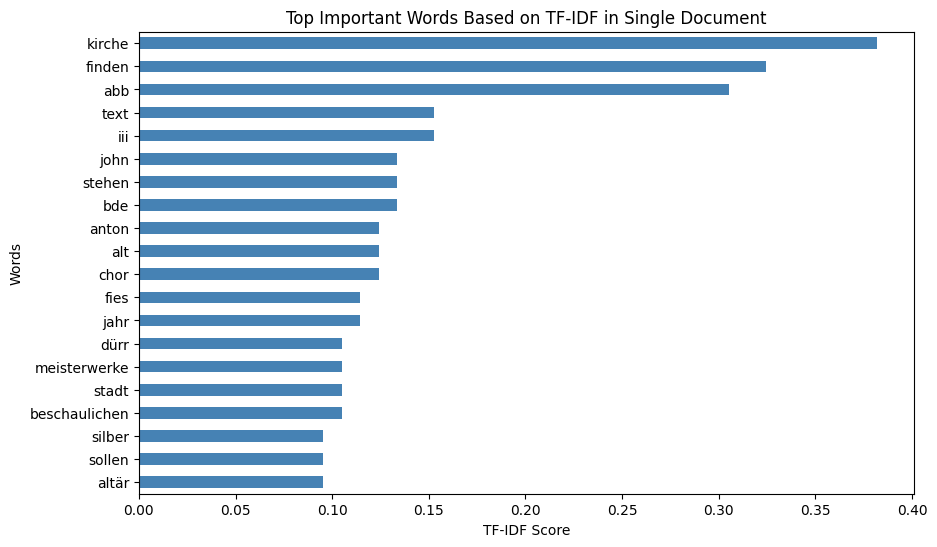

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'tfidf_mean' in locals() and not tfidf_mean.empty:
    plt.figure(figsize=(10, 6))
    tfidf_mean.head(20).plot(kind='barh', color='steelblue')
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Words")
    plt.title("Top Important Words Based on TF-IDF in Single Document")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("TF-IDF mean scores not available for plotting.")

# Note for NER
Do not use cleaned_text saved after spell checker as it is compromised by the spell checker: it destroyed proper nouns and capitalization, removed all digits and all punctuation.

Both the Flair cell and the GLiNER cells (chunk_text_for_gliner, predict_entities(...)) now read from `cleaned_text` (after OCR cleanup and spell-checking) — GLiNER has its own internal subword tokenizer and expects raw, cased, punctuated text.

# NER with Spacy

In [17]:
# load a German language model for NER
nlp = spacy.load("de_core_news_sm")
pd.set_option("display.max_rows", 200)
spacy.prefer_gpu()

False

In [37]:
from spacy import displacy

# Apply NER directly to the single_text (raw text with OCR fixes)
# to avoid issues caused by aggressive spellchecking.
# The 'nlp' German model is loaded in cell '5TYXDvFjWe9Q'.

if single_text:
    # Use single_text for NER
    doc = nlp(single_text)

    print(f"NLP pipeline components: {nlp.pipe_names}") # Diagnostic print to check if 'ner' is in the pipeline

    spacy_entities = []
    for ent in doc.ents:
        spacy_entities.append({
            "text": ent.text,
            "label": ent.label_,
            "lemma": ent.lemma_
        })

    print(f"Found {len(spacy_entities)} entities in the text:")
    for ent_data in spacy_entities[:50]: # Print first 50 entities for brevity
        print(f"  Text: {ent_data['text']}, Label: {ent_data['label']}, Lemma: {ent_data['lemma']}")

    # To visualize entities (optional, might be long for very long texts)
    # If the text is very long, consider visualizing a shorter segment.
    if len(doc.ents) > 0:
        print("\nHTML visualization of entities (first 1000 chars of text):")
        # Use the single_text for displacy
        display(displacy.render(doc[:1000], style="ent", jupyter=True, options={
            "colors": {"ORG": "#aa9cfc", "PER": "#ff8c69", "LOC": "#ffd700", "MISC": "#ccff90"}
        }))
    else:
        print("No entities found to visualize.")
else:
    print("No text available for Named Entity Recognition. Please run the data loading cell first.")
    spacy_entities = [] # Ensure spacy_entities is defined even if no text

NLP pipeline components: ['tok2vec', 'tagger', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']
Found 647 entities in the text:
  Text: St. Fiden, Label: PER, Lemma: St. Fiden
  Text: Jahre 1918, Label: MISC, Lemma: Jahr 1918
  Text: Tablat, Label: LOC, Lemma: Tablat
  Text: Kirche, Label: ORG, Lemma: Kirche
  Text: Vad, Label: MISC, Lemma: vad
  Text: I, Label: MISC, Lemma: I
  Text: S.365, Label: MISC, Lemma: S.365
  Text: Kirche, Label: ORG, Lemma: Kirche
  Text: St. Fiden, Label: MISC, Lemma: St. Fiden
  Text: Eichbohl, Label: LOC, Lemma: Eichbohl
  Text: Die Legende, Label: ORG, Lemma: der Legende
  Text: Kirche, Label: ORG, Lemma: Kirche
  Text: Ulrich III., Label: PER, Lemma: Ulrich III.
  Text: St.-Fides-Heiligtums, Label: LOC, Lemma: St.-Fides-Heiligtum
  Text: Oberrhein, Label: LOC, Lemma: Oberrhein
  Text: Kirche, Label: ORG, Lemma: Kirche
  Text: Schlettstadt, Label: LOC, Lemma: Schlettstadt
  Text: Elsaß, Label: LOC, Lemma: Elsaß
  Text: Hildegard von Hoh

None

## Save spaCy NER Results

Saving the spaCy NER results (`spacy_entities`) to a file allows for efficient loading and further analysis without needing to re-execute the NER process every time.

In [38]:
import joblib
import os

# The spacy_entities list is now populated in cell 'm_SOd5V2WixS'.

if 'spacy_entities' in locals() and spacy_entities:
    # Determine the directory of the original text file
    output_dir = os.path.dirname(text_file_path)
    # Define the output file path for the spaCy entities
    spacy_entities_output_path = os.path.join(output_dir, 'spacy_entities.pkl')

    # Save the spaCy entities using joblib
    joblib.dump(spacy_entities, spacy_entities_output_path)

    print(f"spaCy entities saved to: {spacy_entities_output_path}")
    print(f"Number of entities saved: {len(spacy_entities)}")

    # Optionally, you can load it back to verify
    # loaded_spacy_entities = joblib.load(spacy_entities_output_path)
    # print("Loaded spaCy entities (first 3):", loaded_spacy_entities[:3])
else:
    print("No spaCy entities available to save (list was empty or not defined).")

spaCy entities saved to: /content/drive/MyDrive/Colab Notebooks/NER/spacy_entities.pkl
Number of entities saved: 647


In [39]:
import pandas as pd
import json
import os

if 'spacy_entities' in locals() and spacy_entities:
    # Determine the output directory from your existing path
    output_dir = os.path.dirname(text_file_path)

    # 1. Save as CSV using Pandas
    csv_output_path = os.path.join(output_dir, 'spacy_entities.csv')
    spacy_df = pd.DataFrame(spacy_entities)
    spacy_df.to_csv(csv_output_path, index=False, encoding='utf-8-sig')
    print(f"spaCy entities saved to CSV: {csv_output_path}")

    # 2. Save as JSON
    json_output_path = os.path.join(output_dir, 'spacy_entities.json')
    with open(json_output_path, 'w', encoding='utf-8') as f:
        json.dump(spacy_entities, f, ensure_ascii=False, indent=4)
    print(f"spaCy entities saved to JSON: {json_output_path}")

else:
    print("No spaCy entities available to save.")

spaCy entities saved to CSV: /content/drive/MyDrive/Colab Notebooks/NER/spacy_entities.csv
spaCy entities saved to JSON: /content/drive/MyDrive/Colab Notebooks/NER/spacy_entities.json


# NER with Flair


Compare against a Flair-based tagger. `flair/ner-german-large` is a 4-class model (PER, LOC, ORG, MISC) trained on German data, used zero-shot here (no fine-tuning on this corpus).

In [20]:
!pip install flair

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.8/129.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [21]:
from flair.data import Sentence
from flair.models import SequenceTagger
from flair.splitter import SegtokSentenceSplitter

# Load a pretrained German 4-class NER tagger (PER, LOC, ORG, MISC)
flair_tagger = SequenceTagger.load("flair/ner-german-large")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

2026-09-22 09:39:38,844 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, B-PER, E-PER, S-LOC, B-MISC, I-MISC, E-MISC, S-PER, B-ORG, E-ORG, S-ORG, I-ORG, B-LOC, E-LOC, S-MISC, I-PER, I-LOC, <START>, <STOP>


In [46]:
def run_flair_ner(text):
    """Split text into sentences and tag each one with the Flair NER model."""
    splitter = SegtokSentenceSplitter()
    sentences = splitter.split(text)
    flair_tagger.predict(sentences, mini_batch_size=8) # collect text/label/confidence per entity
    return sentences

if single_text:
    flair_sentences = run_flair_ner(single_text)

    flair_entities = []
    for sent in flair_sentences:
        for entity in sent.get_spans("ner"):
            label = entity.get_label("ner")
            flair_entities.append({
                "text": entity.text,
                "label": label.value,
                "confidence": label.score,
            })

    print(f"Found {len(flair_entities)} entities with Flair:")
    for ent in flair_entities[:50]:
        print(f"  Text: {ent['text']}, Label: {ent['label']}, Confidence: {ent['confidence']:.3f}")
else:
    print("No text available for Flair NER.")
    flair_entities = []

Found 393 entities with Flair:
  Text: St. Fiden, Label: LOC, Confidence: 1.000
  Text: Tablat, Label: LOC, Confidence: 1.000
  Text: St. Fiden, Label: ORG, Confidence: 0.991
  Text: Eichbohl, Label: LOC, Confidence: 1.000
  Text: Eichenhügel, Label: LOC, Confidence: 1.000
  Text: Farna, Label: LOC, Confidence: 1.000
  Text: Ulrich III, Label: PER, Confidence: 1.000
  Text: Oberrhein, Label: LOC, Confidence: 1.000
  Text: Schlettstadt, Label: LOC, Confidence: 1.000
  Text: Elsaß, Label: LOC, Confidence: 1.000
  Text: Hildegard von Hohenstaufen, Label: PER, Confidence: 1.000
  Text: Sainte Foy des Conques, Label: LOC, Confidence: 0.999
  Text: Chur, Label: LOC, Confidence: 1.000
  Text: Schlettstadt, Label: LOC, Confidence: 1.000
  Text: Kollegiatstift Straßburg, Label: ORG, Confidence: 0.999
  Text: St. Gallen, Label: LOC, Confidence: 1.000
  Text: UB, Label: MISC, Confidence: 0.801
  Text: Ulrich VI, Label: PER, Confidence: 1.000
  Text: Ulrich VIII, Label: PER, Confidence: 1.000
  Te

## Save Flair NER Results

Saving the Flair NER results (`flair_entities`) to a file allows you to quickly reload them for further analysis without needing to re-run the potentially time-consuming NER process.

In [48]:
import joblib
import os

if flair_entities:
    # Determine the directory of the original text file
    output_dir = os.path.dirname(text_file_path)
    # Define the output file path for the Flair entities
    flair_entities_output_path = os.path.join(output_dir, 'flair_entities.pkl')

    # Save the Flair entities using joblib
    joblib.dump(flair_entities, flair_entities_output_path)

    print(f"Flair entities saved to: {flair_entities_output_path}")

    # Optionally, you can load it back to verify
    # loaded_flair_entities = joblib.load(flair_entities_output_path)
    # print("Loaded Flair entities (first 3):", loaded_flair_entities[:3])
else:
    print("No Flair entities available to save.")


Flair entities saved to: /content/drive/MyDrive/Colab Notebooks/NER/flair_entities.pkl


In [49]:
if flair_entities:
    flair_df = pd.DataFrame(flair_entities)
    print(flair_df["label"].value_counts())
    display(flair_df.head(50))
else:
    print("No Flair entities to display.")

label
PER     248
LOC     104
MISC     24
ORG      17
Name: count, dtype: int64


,text,label,confidence
0,St. Fiden,LOC,0.999933
1,Tablat,LOC,0.999937
2,St. Fiden,ORG,0.991347
3,Eichbohl,LOC,0.999964
4,Eichenhügel,LOC,0.999973
5,Farna,LOC,0.999957
6,Ulrich III,PER,0.999995
7,Oberrhein,LOC,0.999941
8,Schlettstadt,LOC,0.999990
9,Elsaß,LOC,0.999991


# Custom entity types with GLiNER (zero-shot)

The Flair model is locked to PER/LOC/ORG/MISC. **GLiNER** matches spans against
*arbitrary label names you type in* — no training data needed. We use the
multilingual checkpoint `urchade/gliner_multi-v2.1` (~1.2 GB, cached after first run)
and ask for **dates, buildings, artworks**.

Verified behavior on this corpus:

- **date** works very well (`1918` 0.85, `14. Juli 1778` 0.87, `11. Jahrhundert` 0.96) — trust scores ≥ 0.7
- **artwork** is usable (`Deckenmalereien` 0.72, `Altarblatt` 0.79)
- **building** is the noisiest — it found *Kirche zum Herzen Jesu in St. Fiden* (0.75) but
  also mislabeled a person (*Joh. Michael Grass*, 0.52) — treat scores below ~0.6 with suspicion

Tune `GLINER_LABELS` (English label names work best, even on German text) and
`GLINER_THRESHOLD` (raise to 0.5–0.6 for cleaner but fewer results). GLiNER results are
kept in a separate `gliner_entities.csv` — combine with the Flair entities downstream
as needed.

In [43]:
# Run once per environment (already installed in the 'ner' env)
%pip install -q gliner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.0/262.0 kB 8.8 MB/s eta 0:00:00


In [50]:
from gliner import GLiNER

gliner_model = GLiNER.from_pretrained("urchade/gliner_multi-v2.1")

# Threshold trades precision vs. recall.
GLINER_LABELS = ["date", "building", "church or religious building", "part of a building",
                 "intervention", "artwork", "person", "place like city, village, region", "architectural element", "organization"]
GLINER_THRESHOLD = 0.4

gl_rows = []
for i, sent in enumerate(flair_sentences):
    for ent in gliner_model.predict_entities(
        sent.text, GLINER_LABELS, threshold=GLINER_THRESHOLD
    ):
        gl_rows.append(
            {
                "sentence_id": i,
                "text": ent["text"],
                "label": ent["label"],
                "score": round(ent["score"], 3),
                "start": ent["start"],
                "end": ent["end"],
                "sentence": sent.text,
            }
        )

gliner_df = pd.DataFrame(gl_rows)
gliner_df.to_csv(os.path.join(output_dir, "gliner_entities.csv"), index=False, encoding="utf-8-sig")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [51]:
print(f"{len(gliner_df)} spans → {os.path.join(output_dir, 'gliner_entities.csv')}\n")
print(gliner_df["label"].value_counts(), "\n")
display(gliner_df.sort_values("score", ascending=False).head(50)[["text", "label", "score"]])
print("\nLow-confidence spans (most likely errors):")
display(gliner_df.sort_values("score").head(50)[["text", "label", "score", "sentence"]])

766 spans → /content/drive/MyDrive/Colab Notebooks/NER/gliner_entities.csv

label
person                              214
date                                175
building                            108
artwork                              84
architectural element                54
church or religious building         47
place like city, village, region     30
organization                         24
part of a building                   22
intervention                          8
Name: count, dtype: int64 



,text,label,score
681,Ferdinand Beer,person,0.991
341,Joachim Lutz,person,0.987
213,Ferdinand Beer,person,0.987
713,Antoni Dick,person,0.986
64,Ferdinand Beer,person,0.984
92,Michael Grass,person,0.982
89,Franz Antoni Dürr,person,0.981
707,Erwin Poeschel,person,0.981
480,Ulrich von Notkersegg,person,0.978
651,Scherrer,person,0.976



Low-confidence spans (most likely errors):


,text,label,score,sentence
470,Vier Glocken,artwork,0.401,"Vier Glocken, eine davon unbekannten Datums, d..."
686,Thieme-Becker,person,0.401,"SKL IV, S.318, Thieme-Becker, Bd."
522,Grundriß,architectural element,0.401,Grundriß.
329,Altären,building,0.403,Neben den Altären jeweils kleine Kartuschen mi...
280,Kompositkapitellen,architectural element,0.403,Das Hauptbild des bestehenden Hochaltars flank...
104,Seelenkapelle,building,0.404,"1789 Neuerrichtung des Altars, der ehemals in ..."
286,vier Statuen,artwork,0.404,Zu Füßen der Säulen stehen vier Statuen: die K...
411,Stenglin,"place like city, village, region",0.405,"Stenglin, nach Schröder Nr.40 wahrscheinlicher..."
278,Hauptbild,artwork,0.405,Das Hauptbild des bestehenden Hochaltars flank...
11,Eichbohl,part of a building,0.405,Ehemals hieß die Gegend «Eichbohl» (Eichenhüge...


## Refining GLiNER: sharper labels + multi-label scoring

Split the overloaded `"church or religious building"` label into a separate `"architectural element"` type, and rerun with `multi_label=True` and a lower threshold so GLiNER returns every label it considered for a span, not just the winner. Spans are grouped and sorted by how close the top two competing label scores are — a small gap means the model was genuinely torn between two labels for that span, which is a better signal for manual review than the raw confidence score.

In [52]:
from flair.splitter import SegtokSentenceSplitter

def chunk_text_for_gliner(text, max_chars=800):
    """Split text into sentences and greedily pack them into chunks under GLiNER's token budget."""
    splitter = SegtokSentenceSplitter()
    sentences = [s.to_original_text() for s in splitter.split(text)]

    chunks, current = [], ""
    for sent in sentences:
        if current and len(current) + len(sent) > max_chars:
            chunks.append(current.strip())
            current = ""
        current += sent + " "
    if current.strip():
        chunks.append(current.strip())
    return chunks

if single_text:
    gliner_chunks = chunk_text_for_gliner(single_text)

    gliner_entities = []
    for chunk in gliner_chunks:
        preds = gliner_model.predict_entities(chunk, GLINER_LABELS, threshold=0.5)
        for ent in preds:
            gliner_entities.append({
                "text": ent["text"],
                "label": ent["label"],
                "confidence": ent["score"],
            })

    print(f"Found {len(gliner_entities)} entities with GLiNER:")
    for ent in gliner_entities[:50]:
        print(f"  Text: {ent['text']}, Label: {ent['label']}, Confidence: {ent['confidence']:.3f}")
else:
    print("No text available for GLiNER NER.")
    gliner_entities = []

Found 278 entities with GLiNER:
  Text: St. Fiden, Label: church or religious building, Confidence: 0.598
  Text: 1918, Label: date, Confidence: 0.542
  Text: Kirche, Label: church or religious building, Confidence: 0.612
  Text: 1426, Label: date, Confidence: 0.587
  Text: Kirche, Label: church or religious building, Confidence: 0.697
  Text: 1777, Label: date, Confidence: 0.579
  Text: St. Fiden, Label: church or religious building, Confidence: 0.532
  Text: Kirche, Label: church or religious building, Confidence: 0.545
  Text: Abt Ulrich III, Label: person, Confidence: 0.852
  Text: 11. Jahrhunderts, Label: date, Confidence: 0.711
  Text: Kirche und Kloster, Label: church or religious building, Confidence: 0.529
  Text: Schlettstadt, Label: place like city, village, region, Confidence: 0.503
  Text: Hildegard von Hohenstaufen, Label: person, Confidence: 0.820
  Text: Abtei Sainte Foy des Conques, Label: organization, Confidence: 0.564
  Text: Bistum Chur, Label: organization, Confid

In [53]:
if gliner_entities:
    gliner_df = pd.DataFrame(gliner_entities)
    print(gliner_df["label"].value_counts())
    display(gliner_df.head(20))
else:
    print("No GLiNER entities to display.")

label
person                              117
date                                 74
church or religious building         44
artwork                              15
architectural element                 7
building                              6
part of a building                    5
organization                          5
place like city, village, region      4
intervention                          1
Name: count, dtype: int64


,text,label,confidence
0,St. Fiden,church or religious building,0.597526
1,1918,date,0.541558
2,Kirche,church or religious building,0.611759
3,1426,date,0.586687
4,Kirche,church or religious building,0.696530
5,1777,date,0.579352
6,St. Fiden,church or religious building,0.532098
7,Kirche,church or religious building,0.544692
8,Abt Ulrich III,person,0.851503
9,11. Jahrhunderts,date,0.711211


In [54]:
# Refined label set (if needed): split "church or religious building" into building vs. architectural element,
# and lower the threshold with multi_label=True so we can see competing label scores per span.
gliner_labels_refined = [
    "date", "building", "church or religious building", "interior space", "subject of a drawing or painting", "intervention", "artwork or ornament", "name of person", "profession of a person", "place (like city, village, region)", "architectural element", "organization"
]

if single_text:
    gliner_mentions_refined = []
    for chunk_idx, chunk in enumerate(gliner_chunks):
        preds = gliner_model.predict_entities(
            chunk, gliner_labels_refined, threshold=0.3, multi_label=True
        )
        for ent in preds:
            # Keep chunk index + character offsets so each occurrence is tracked separately,
            # instead of collapsing every mention of the same surface text into one group.
            gliner_mentions_refined.append({
                "chunk": chunk_idx,
                "start": ent["start"],
                "end": ent["end"],
                "text": ent["text"],
                "label": ent["label"],
                "confidence": ent["score"],
            })

    mentions_df = pd.DataFrame(gliner_mentions_refined)

    if not mentions_df.empty:
        # Group by the exact occurrence (chunk + character span), not just surface text,
        # so "gap" only ever compares labels that genuinely competed for the same mention.
        mention_groups = (
            mentions_df.sort_values("confidence", ascending=False)
            .groupby(["chunk", "start", "end", "text"])
            .agg(labels=("label", list), scores=("confidence", list))
            .reset_index()
        )

        def score_gap(scores):
            # Small gap between the top two competing labels = the model was genuinely torn
            return scores[0] - scores[1] if len(scores) > 1 else 1.0

        mention_groups["gap"] = mention_groups["scores"].apply(score_gap)
        mention_groups = mention_groups.sort_values("gap")

        print("Individual mentions with the most ambiguous (closely competing) label predictions:")
        display(mention_groups.head(20))

        # Separately: the same surface text appearing at different positions is NOT label
        # ambiguity — it's expected score variance from different surrounding context.
        repeated_text_variance = (
            mention_groups.groupby("text")["scores"]
            .apply(lambda score_lists: [scores[0] for scores in score_lists])
            .reset_index(name="top_score_per_occurrence")
        )
        repeated_text_variance = repeated_text_variance[
            repeated_text_variance["top_score_per_occurrence"].apply(len) > 1
        ]

        print("\nSame text at multiple positions (score varies by context, not by label competition):")
        display(repeated_text_variance.head(50))
    else:
        print("No entities found with the refined label set.")
else:
    print("No original text available for refined GLiNER NER.")
    gliner_mentions_refined = []

Individual mentions with the most ambiguous (closely competing) label predictions:


,chunk,start,end,text,labels,scores,gap
402,41,293,302,Besenwurf,"[artwork or ornament, architectural element]","[0.42601844668388367, 0.42367562651634216]",0.002343
199,21,267,279,Altarblattes,"[architectural element, artwork or ornament]","[0.31863537430763245, 0.30861392617225647]",0.010021
406,41,493,504,Besenwurfes,"[architectural element, artwork or ornament]","[0.44115495681762695, 0.43050336837768555]",0.010652
141,13,533,546,Restaurierung,"[date, intervention]","[0.5135741233825684, 0.4953010082244873]",0.018273
412,42,247,262,Museum Konstanz,"[organization, building]","[0.45826947689056396, 0.43424052000045776]",0.024029
134,12,606,610,Chor,"[church or religious building, building]","[0.4613296091556549, 0.4344739615917206]",0.026856
384,39,150,161,Stiftsarch.,"[profession of a person, name of person]","[0.6298937201499939, 0.6000156998634338]",0.029878
314,34,73,82,Meisterin,"[name of person, profession of a person]","[0.40833449363708496, 0.3612940013408661]",0.047040
416,42,662,677,Museum Konstanz,"[building, organization]","[0.4661933183670044, 0.41093167662620544]",0.055262
389,39,426,437,Stiftsarch.,"[profession of a person, name of person]","[0.6462740898132324, 0.5837944746017456]",0.062480



Same text at multiple positions (score varies by context, not by label competition):


,text,top_score_per_occurrence
6,1303,"[0.6443735361099243, 0.3839147388935089]"
23,1707,"[0.39002957940101624, 0.35188010334968567]"
25,1708,"[0.5591410994529724, 0.4481047987937927]"
35,1767/69,"[0.6310205459594727, 0.46421632170677185]"
38,1777,"[0.6042995452880859, 0.9595317244529724]"
40,1778,"[0.9178069829940796, 0.727851152420044, 0.7781..."
42,1784,"[0.7810115814208984, 0.6771548390388489, 0.470..."
44,1799,"[0.39492347836494446, 0.30128005146980286]"
47,1853,"[0.7357420325279236, 0.3530830144882202]"
50,1874,"[0.8056470155715942, 0.7467958331108093, 0.530..."


Now tracks each occurrence by (chunk, start, end) character offsets instead of grouping by surface text alone — so mention_groups/gap only ever compares labels that competed for the same specific mention, not different sentences that happen to contain the same word.
- Added a second table, repeated_text_variance, that separately shows cases like "Rokokokelch" appearing multiple times with different top scores — labeled explicitly as expected context-driven variance, not ambiguity, so you don't mistake one for the other.

In [55]:
if gliner_mentions_refined:
    gliner_df_refined = pd.DataFrame(gliner_mentions_refined)
    print(gliner_df_refined["label"].value_counts())
    display(gliner_df_refined.head(50))
else:
    print("No GLiNER entities refined to display.")

label
date                                  107
name of person                        107
church or religious building           70
building                               36
architectural element                  34
place (like city, village, region)     32
artwork or ornament                    31
interior space                         29
organization                           18
profession of a person                 15
intervention                            1
subject of a drawing or painting        1
Name: count, dtype: int64


,chunk,start,end,text,label,confidence
0,0,30,39,St. Fiden,church or religious building,0.615447
1,0,30,39,St. Fiden,"place (like city, village, region)",0.368321
2,0,60,64,1918,date,0.450611
3,0,93,99,Tablat,"place (like city, village, region)",0.390958
4,0,142,155,Stadtgebietes,"place (like city, village, region)",0.319717
5,0,258,264,Kirche,church or religious building,0.580165
6,0,275,279,Haus,church or religious building,0.369351
7,0,303,307,1426,date,0.591321
8,0,331,335,Räte,organization,0.316743
9,0,340,367,städtischen Gerichtsbarkeit,organization,0.475706


## Save Refined GLiNER Results

Saving the refined GLiNER entities to CSV and JSON formats.

In [56]:
import pandas as pd
import json
import os

if 'gliner_mentions_refined' in locals() and gliner_mentions_refined:
    output_dir = os.path.dirname(text_file_path)

    # 1. Save as CSV
    csv_output_path = os.path.join(output_dir, 'gliner_entities_refined.csv')
    gliner_df_refined = pd.DataFrame(gliner_mentions_refined)
    gliner_df_refined.to_csv(csv_output_path, index=False, encoding='utf-8-sig')
    print(f"Refined GLiNER entities saved to CSV: {csv_output_path}")

    # 2. Save as JSON
    json_output_path = os.path.join(output_dir, 'gliner_entities_refined.json')
    with open(json_output_path, 'w', encoding='utf-8') as f:
        json.dump(gliner_mentions_refined, f, ensure_ascii=False, indent=4)
    print(f"Refined GLiNER entities saved to JSON: {json_output_path}")
else:
    print("No refined GLiNER entities available to save.")

Refined GLiNER entities saved to CSV: /content/drive/MyDrive/Colab Notebooks/NER/gliner_entities_refined.csv
Refined GLiNER entities saved to JSON: /content/drive/MyDrive/Colab Notebooks/NER/gliner_entities_refined.json


In [57]:
gliner_df_refined.head(100)

,chunk,start,end,text,label,confidence
0,0,30,39,St. Fiden,church or religious building,0.615447
1,0,30,39,St. Fiden,"place (like city, village, region)",0.368321
2,0,60,64,1918,date,0.450611
3,0,93,99,Tablat,"place (like city, village, region)",0.390958
4,0,142,155,Stadtgebietes,"place (like city, village, region)",0.319717
5,0,258,264,Kirche,church or religious building,0.580165
6,0,275,279,Haus,church or religious building,0.369351
7,0,303,307,1426,date,0.591321
8,0,331,335,Räte,organization,0.316743
9,0,340,367,städtischen Gerichtsbarkeit,organization,0.475706
